# Análisis End-to-End de Neurona Individual

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('.'))

from scripts.utils import (
    _cargar_datos_neurona,
    preparar_datos_posicion,
    preparar_datos_head_direction,
    preparar_datos_mirada,
    firing_map
)

from scripts.utils.angulo_preferido import (
    analizar_sintonizacion_perspectiva_continua,
    evaluar_confianza_sintonizacion_perspectiva
)

from scripts.utils.cross_validation import (
    generate_all_splits,
    cross_validate_gam_grid,
    select_best_1se_gam,
    retrain_best_gam,
    poisson_nll_per_sample,
    null_model_nll,
    pseudo_r2_mcfadden
)

from scripts.utils.shapley_values import calculate_shapley_values, plot_shapley_values


## 1. Configuración de Parámetros

In [2]:
sesion = 2
tetrodo = 2
neurona = 5
bin_size_sec = 0.1

## 2. Firing Map

-> graficando s=2, t=2, c=5. disparos: 494


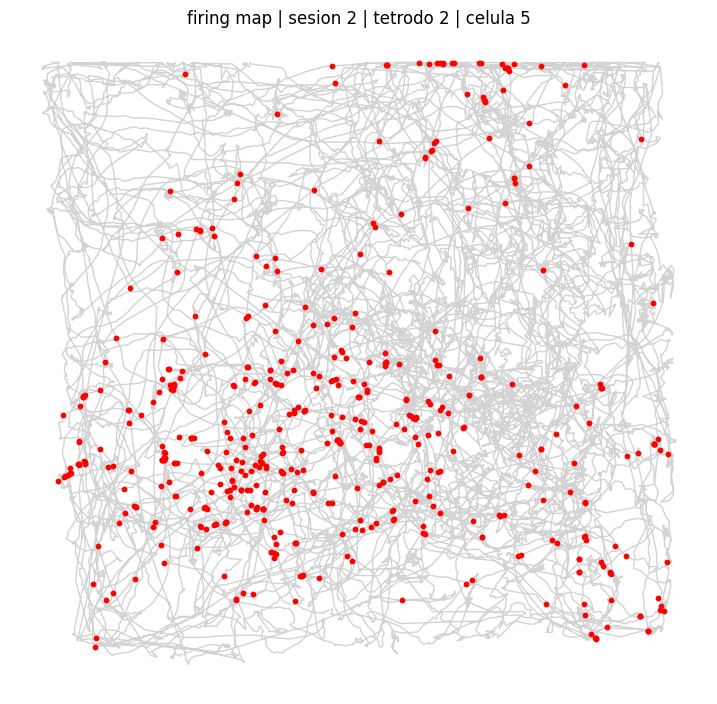

In [3]:
firing_map(sesion, tetrodo, neurona)
plt.show()

## 3. Análisis de Viewpoint

In [4]:
# ---- Parámetros de la grilla y análisis ----
grid_res = 25

x_bins, y_bins, ang_bins_rad, spikes_gaze = preparar_datos_mirada(sesion, tetrodo, neurona, bin_size_sec)

res_persp = analizar_sintonizacion_perspectiva_continua(
    x_bins, y_bins, ang_bins_rad, spikes_gaze, tiempos_bin=bin_size_sec, grid_res=grid_res
)
x_best_p, y_best_p = res_persp['best_coord']
print(f"Coordenada Óptima de Perspectiva: X={x_best_p:.2f}, Y={y_best_p:.2f}")
print(f"Amplitud de Proyección Máxima: {res_persp['persp_indx']:.4f} Hz")

res_sig = evaluar_confianza_sintonizacion_perspectiva(
    x_bins, y_bins, ang_bins_rad, spikes_gaze, tiempos_bin=bin_size_sec, grid_res=grid_res, n_shifts=100, min_shift_sec=10.0
)
print(f"Z-score: {res_sig['z_score']:.2f}, Significativo: {res_sig['confianza_significativa']}")

Coordenada Óptima de Perspectiva: X=-10.38, Y=-5.19
Amplitud de Proyección Máxima: 0.2362 Hz
Z-score: 4.80, Significativo: True


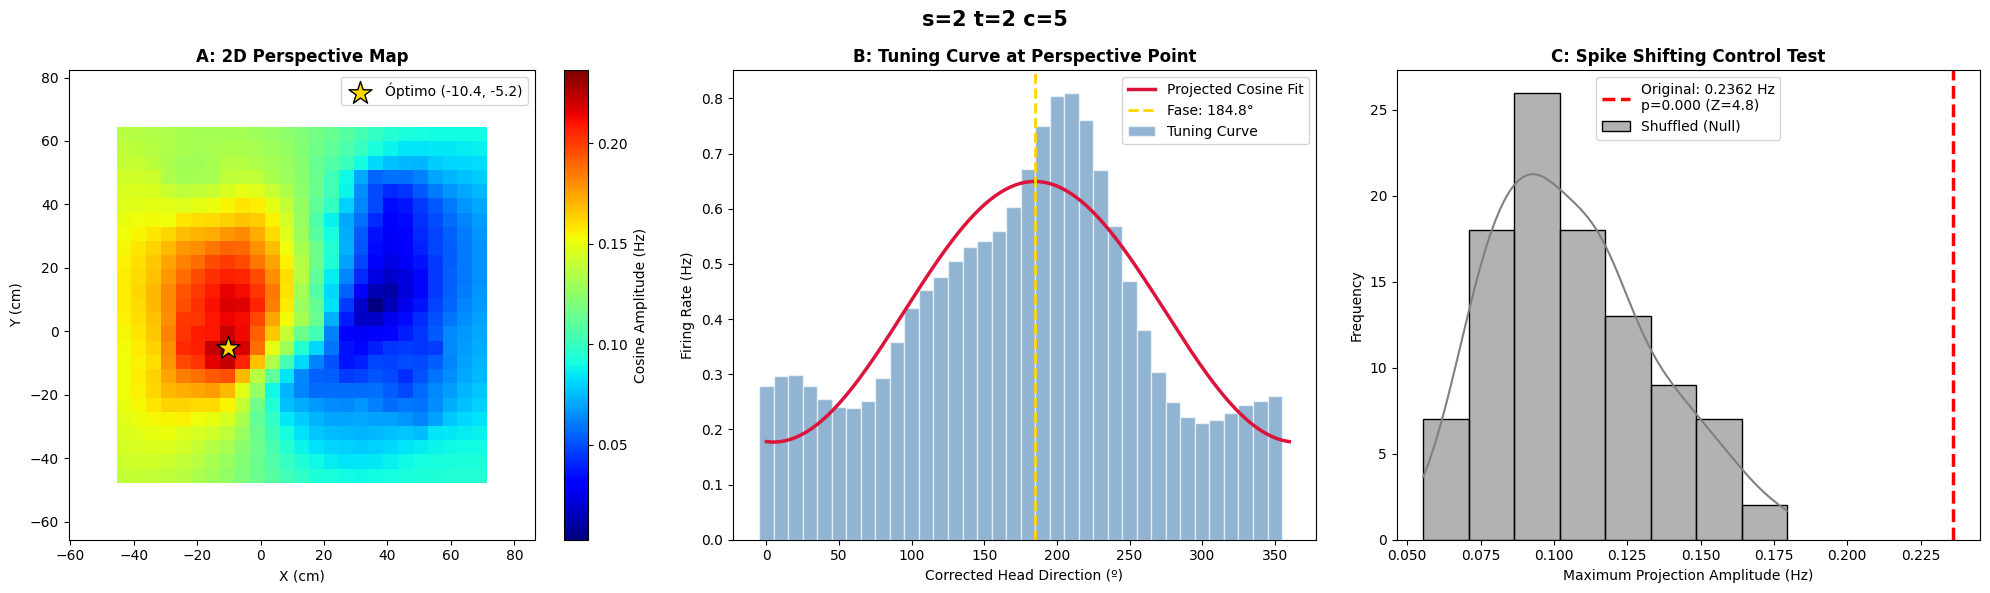

In [5]:
# ---- Generar visualización. 3 paneles ----
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# # ---- Generar visualización. 2 paneles ----
# fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Panel 1: Heatmap de Perspectiva
ax1 = axes[0]
XX_p = res_persp['XX']
YY_p = res_persp['YY']
map_p_matrix = res_persp['map_p_matrix']
mesh1 = ax1.pcolormesh(XX_p, YY_p, map_p_matrix, cmap='jet', shading='nearest')
fig.colorbar(mesh1, ax=ax1, label='Cosine Amplitude (Hz)')
ax1.scatter(x_best_p, y_best_p, color='gold', marker='*', s=300, edgecolor='black', zorder=10, label=f'Óptimo ({x_best_p:.1f}, {y_best_p:.1f})')
ax1.set_title('A: 2D Perspective Map', fontweight='bold')
ax1.set_xlabel('X (cm)')
ax1.set_ylabel('Y (cm)')
ax1.axis('equal')
ax1.legend()

# Panel 2: Tuning Curve Corregida y Modelo de Coseno Ajustado
ax2 = axes[1]
hdbins_deg = np.degrees(res_persp['hdbins'])
tuning_curve_best = res_persp['tuning_curve_best']
ax2.bar(hdbins_deg, tuning_curve_best, width=360/36, alpha=0.6, color='steelblue', edgecolor='white', label='Tuning Curve')

# Graficar modelo ajustado de coseno
x_fit = np.linspace(0, 360, 500)
rate_mean = np.mean(spikes_gaze) / bin_size_sec
y_fit = rate_mean + res_persp['persp_indx'] * np.cos(np.radians(x_fit) - res_persp['theta0'])
y_fit = np.clip(y_fit, 0, None)
ax2.plot(x_fit, y_fit, color='crimson', linewidth=2.5, label='Projected Cosine Fit')
ax2.axvline(np.degrees(res_persp['theta0']), color='gold', linestyle='--', linewidth=2, label=f'Fase: {np.degrees(res_persp["theta0"]):.1f}°')
ax2.set_xlabel('Corrected Head Direction (º)')
ax2.set_ylabel('Firing Rate (Hz)')
ax2.set_title('B: Tuning Curve at Perspective Point', fontweight='bold')
ax2.legend()

# Panel 3: Distribución Nula mediante Spike Shifting
ax3 = axes[2]
sns.histplot(res_sig['shuffled_persp_indxs'], ax=ax3, color='gray', alpha=0.6, kde=True, label='Shuffled (Null)')
ax3.axvline(res_sig['original_persp_indx'], color='red', linestyle='--', linewidth=2.5,
            label=f'Original: {res_sig["original_persp_indx"]:.4f} Hz\np={res_sig["p_value"]:.3f} (Z={res_sig["z_score"]:.1f})')
ax3.set_title('C: Spike Shifting Control Test', fontweight='bold')
ax3.set_xlabel('Maximum Projection Amplitude (Hz)')
ax3.set_ylabel('Frequency')
ax3.legend()

plt.suptitle(f's={sesion} t={tetrodo} c={neurona}', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 4. Preparación de Datos para GAMs

In [13]:
# Datos para Head Direction
ang_bins_deg, spikes_hd = preparar_datos_head_direction(sesion, tetrodo, neurona, bin_size_sec=bin_size_sec)
hd_rad = np.radians(ang_bins_deg)

# Datos corregidos para Viewpoint
dy = y_best_p - y_bins
dx = x_best_p - x_bins
ang_hacia_punto = np.arctan2(dy, dx)
theta_corrected = np.mod(ang_bins_rad - ang_hacia_punto, 2 * np.pi)
distances = np.sqrt((x_bins - x_best_p)**2 + (y_bins - y_best_p)**2)

# Consolidamos X_cv asumiendo el mismo tamaño de arrays
X_cv = np.column_stack((x_bins, y_bins, theta_corrected, distances, hd_rad))
Y_cv = spikes_gaze

folds, held_out_idx, train_pool_idx, roles = generate_all_splits(
    n_muestras=len(X_cv),
    bin_size_sec=bin_size_sec,
    block_size_sec=60,
    n_folds=5,
    buffer_sec=2
)

X_pool, Y_pool = X_cv[train_pool_idx], Y_cv[train_pool_idx]
X_held, Y_held = X_cv[held_out_idx], Y_cv[held_out_idx]

# ============================================================================
# Configuración de grillas por modelo (Grid Search custom).
# 
# Los modelos que no estén explícitamente en este diccionario (los que ya 
# funcionaron bien) usarán automáticamente la configuración 'default'.
# Todos evalúan exactamente 7 valores para mantener el tiempo de ejecución.
# ============================================================================

grid_configs = {
    # --- Grilla por defecto (Para 'Pos', 'Pos + View', etc.) ---
    'default': {
        'splines': [9],
        'lambdas': np.logspace(-1, 1, 7),  # 7 valores: de 0.1 a 10.0
    },

    # --- Modelos que eligieron el MÍNIMO (0.1) ---
    # Necesitan explorar lambdas menores (menos regularización)
    'Viewpoint': {
        'splines': [9],
        'lambdas': np.logspace(-3, 1, 7),  # 7 valores: de 0.001 a 10.0
    },
    'Dist': {
        'splines': [9],
        'lambdas': np.logspace(-3, 1, 7),  # 7 valores: de 0.001 a 10.0
    },

    # --- Modelos que eligieron el MÁXIMO (10.0) ---
    # Necesitan explorar lambdas mayores (más regularización)
    'HD': {
        'splines': [9],
        'lambdas': np.logspace(0, 3, 7),   # 7 valores: de 1.0 a 1000.0
    },
    'View + HD': {
        'splines': [9],
        'lambdas': np.logspace(0, 3, 7),   # 7 valores: de 1.0 a 1000.0
    },
}

## 5. Cross-Validation: Posición, Viewpoint, Joint (Pos + View + Distancia)

In [14]:
# Diccionario con configuraciones de cada modelo
# cols indica las columnas en X_cv que se extraen para entrenar
modelos_a_evaluar = {
    'Pos': {'cols': [0, 1], 'type': 'pos'},
    'Viewpoint': {'cols': [2], 'type': 'view_angle'},
    'HD': {'cols': [4], 'type': 'view_angle'},
    'Dist': {'cols': [3], 'type': 'dist'},
    'Pos + View': {'cols': [0, 1, 2], 'type': 'pos_view_angle'},
    'Pos + HD': {'cols': [0, 1, 4], 'type': 'pos_hd'},
    'Pos + Dist': {'cols': [0, 1, 3], 'type': 'pos_dist'},
    'View + HD': {'cols': [2, 4], 'type': 'view_hd'},
    'View + Dist': {'cols': [2, 3], 'type': 'view_angle_dist'},
    'HD + Dist': {'cols': [4, 3], 'type': 'view_angle_dist'},
    'Pos + View + HD': {'cols': [0, 1, 2, 4], 'type': 'pos_view_hd'},
    'Pos + View + Dist': {'cols': [0, 1, 2, 3], 'type': 'pos_view_angle_dist'},
    'Pos + HD + Dist': {'cols': [0, 1, 4, 3], 'type': 'pos_hd_dist'},
    'View + HD + Dist': {'cols': [2, 4, 3], 'type': 'view_hd_dist'},
    'Pos + View + HD + Dist': {'cols': [0, 1, 2, 4, 3], 'type': 'pos_view_hd_dist'}
}

resultados_modelos = {}

for nombre, config in modelos_a_evaluar.items():
    print(f"\n{'='*60}")
    print(f"--- Evaluando modelo: {nombre} ---")
    cols = config['cols']
    m_type = config['type']
    
    # Obtener grilla específica del modelo, o usar default
    gc = grid_configs.get(nombre, grid_configs['default'])
    splines_modelo = gc['splines']
    lambdas_modelo = gc['lambdas']
    print(f"    Grilla: splines={splines_modelo}, lambdas=[{lambdas_modelo[0]:.4g} ... {lambdas_modelo[-1]:.4g}] ({len(lambdas_modelo)} valores)")
    
    # Extraemos solo las columnas relevantes
    X_subset = X_cv[:, cols]
    
    # 1. Validación cruzada en la grilla de hiperparámetros
    _, res_cv = cross_validate_gam_grid(
        X_subset, Y_cv, folds,
        splines_modelo,   # <-- grilla específica del modelo
        lambdas_modelo,   # <-- grilla específica del modelo
        model_type=m_type
    )
    
    # 2. Seleccionar el mejor hiperparámetro (Mínimo NLL puro, ignorando 1-SE)
    mejor_min, _, _ = select_best_1se_gam(res_cv)
    best_sp = int(mejor_min[0])
    best_lam = mejor_min[1]
        
    print(f"Mejor configuración (Min NLL): splines={best_sp}, lambda={best_lam:.4g}")
    
    # 3. Re-entrenar con todos los datos del pool de entrenamiento
    X_pool_subset = X_pool[:, cols]
    modelo_final = retrain_best_gam(X_pool_subset, Y_pool, best_sp, best_lam, model_type=m_type)
    
    # Guardamos los resultados
    resultados_modelos[nombre] = {
        'modelo': modelo_final,
        'cols': cols,
        'best_splines': best_sp,
        'best_lambda': best_lam,
        'lambda_range': (lambdas_modelo[0], lambdas_modelo[-1]),
    }



--- Evaluando modelo: Pos ---
    Grilla: splines=[9], lambdas=[0.1 ... 10] (7 valores)
sp= 9, lam= 0.1000000 | edof:  20.3602 | nll test: 0.14936277 (± 0.01629390)
sp= 9, lam= 0.2154435 | edof:  16.9898 | nll test: 0.14921102 (± 0.01634931)
sp= 9, lam= 0.4641589 | edof:  14.0774 | nll test: 0.14942217 (± 0.01641910)
sp= 9, lam= 1.0000000 | edof:  11.6207 | nll test: 0.15018581 (± 0.01652114)
sp= 9, lam= 2.1544347 | edof:   9.5561 | nll test: 0.15161878 (± 0.01668829)
sp= 9, lam= 4.6415888 | edof:   7.8403 | nll test: 0.15350751 (± 0.01692509)
sp= 9, lam=10.0000000 | edof:   6.4712 | nll test: 0.15538794 (± 0.01717043)
Mejor configuración (Min NLL): splines=9, lambda=0.2154

--- Evaluando modelo: Viewpoint ---
    Grilla: splines=[9], lambdas=[0.001 ... 10] (7 valores)
sp= 9, lam= 0.0010000 | edof:   8.9771 | nll test: 0.15767501 (± 0.01572341)
sp= 9, lam= 0.0046416 | edof:   8.8980 | nll test: 0.15762852 (± 0.01573106)
sp= 9, lam= 0.0215443 | edof:   8.6004 | nll test: 0.15746622 (± 

Modelo Nulo (NLL): 0.2467

Pos                  | NLL: 0.2205 | Pseudo R²: 0.1062
Viewpoint            | NLL: 0.2458 | Pseudo R²: 0.0038
HD                   | NLL: 0.2530 | Pseudo R²: -0.0256
Dist                 | NLL: 0.2239 | Pseudo R²: 0.0924
Pos + View           | NLL: 0.2220 | Pseudo R²: 0.1004
Pos + HD             | NLL: 0.2239 | Pseudo R²: 0.0927
Pos + Dist           | NLL: 0.2205 | Pseudo R²: 0.1061
View + HD            | NLL: 0.2500 | Pseudo R²: -0.0132
View + Dist          | NLL: 0.2261 | Pseudo R²: 0.0835
HD + Dist            | NLL: 0.2286 | Pseudo R²: 0.0733
Pos + View + HD      | NLL: 0.2243 | Pseudo R²: 0.0908
Pos + View + Dist    | NLL: 0.2213 | Pseudo R²: 0.1033
Pos + HD + Dist      | NLL: 0.2234 | Pseudo R²: 0.0944
View + HD + Dist     | NLL: 0.2285 | Pseudo R²: 0.0738
Pos + View + HD + Dist | NLL: 0.2232 | Pseudo R²: 0.0955


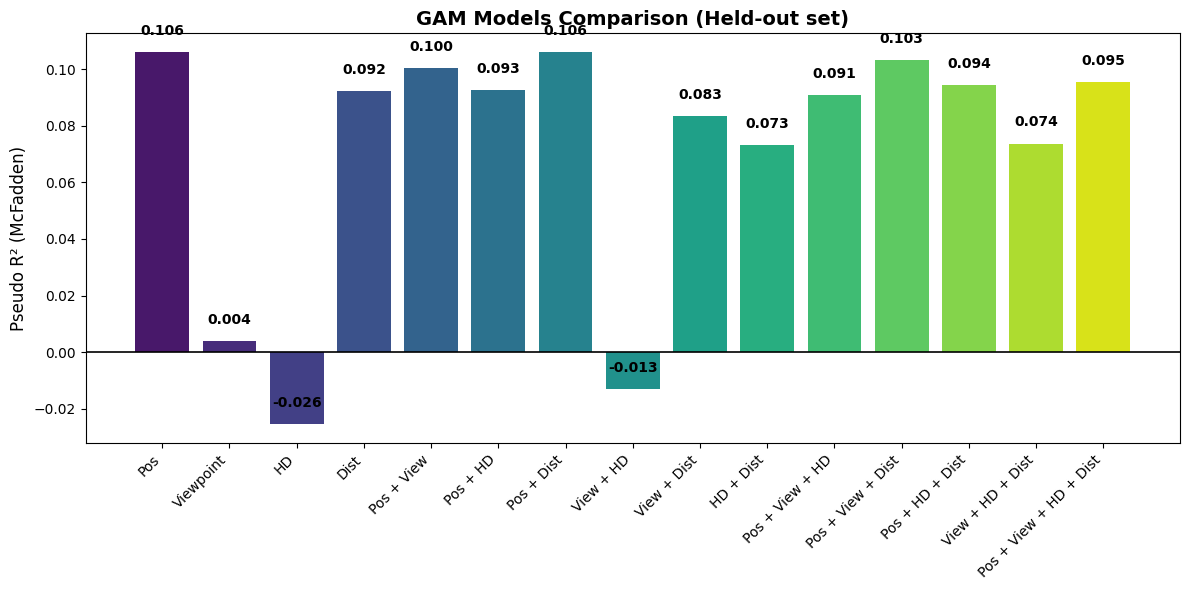


Shapley Values...
Mejor modelo: Pos (Pseudo R2 = 0.106164)

No se requiere análisis de Shapley.


In [15]:
# ---- Evaluación Final en Held-out (Pseudo R²) ----
nll_null = null_model_nll(Y_pool, Y_held)
print(f"Modelo Nulo (NLL): {nll_null:.4f}\n")

r2_scores = {}

for nombre, datos in resultados_modelos.items():
    modelo = datos['modelo']
    cols = datos['cols']
    
    # Extraemos los datos del held-out set para predecir
    X_held_subset = X_held[:, cols]
    
    # Predicción (mu)
    mu_pred = modelo.predict(X_held_subset)
    
    # Calculamos NLL y McFadden's Pseudo R²
    nll_model = poisson_nll_per_sample(Y_held, mu_pred)
    r2 = pseudo_r2_mcfadden(nll_model, nll_null)
    
    r2_scores[nombre] = r2
    print(f"{nombre:<20} | NLL: {nll_model:.4f} | Pseudo R²: {r2:.4f}")

# ---- Gráfico de Barras ----
plt.figure(figsize=(12, 6))
nombres = list(r2_scores.keys())
valores_r2 = list(r2_scores.values())

bars = plt.bar(nombres, valores_r2, color=sns.color_palette("viridis", len(nombres)))
plt.axhline(0, color='black', linewidth=1.2)
plt.ylabel('Pseudo R² (McFadden)', fontsize=12)
plt.title('GAM Models Comparison (Held-out set)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Añadir valores arriba de las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


# ---- Análisis de Shapley Values ----
print("\n" + "="*40)
print("Shapley Values...")
print("="*40)

# 1. Selección del mejor modelo
best_model_name = max(r2_scores, key=r2_scores.get)
best_r2_val = r2_scores[best_model_name]

print(f"Mejor modelo: {best_model_name} (Pseudo R2 = {best_r2_val:.6f})\n")

ganadoras = best_model_name.split(' + ')

# 2. Filtro de Shapley: si es una sola variable, es célula pura
if len(ganadoras) == 1:
    print(f"No se requiere análisis de Shapley.")
else:
    mapping_keys = {
        'Pos': 'shapley_pos',
        'Viewpoint': 'shapley_view',
        'HD': 'shapley_hd',
        'Dist': 'shapley_dist',
        'Pos + View': 'shapley_pos_view',
        'Pos + HD': 'shapley_pos_hd',
        'Pos + Dist': 'shapley_pos_dist',
        'View + HD': 'shapley_view_hd',
        'View + Dist': 'shapley_view_dist',
        'HD + Dist': 'shapley_hd_dist',
        'Pos + View + HD': 'shapley_pos_view_hd',
        'Pos + View + Dist': 'shapley_pos_view_dist',
        'Pos + HD + Dist': 'shapley_pos_hd_dist',
        'View + HD + Dist': 'shapley_view_hd_dist',
        'Pos + View + HD + Dist': 'shapley_pos_view_hd_dist'
    }

    # 3. Construcción dinámica: descartar variables que no estén en el modelo ganador
    r2_for_shapley = {'null': 0.0}
    for name, r2_val in r2_scores.items():
        variables_in_model = name.split(' + ')
        if all(var in ganadoras for var in variables_in_model):
            if name in mapping_keys:
                r2_for_shapley[mapping_keys[name]] = r2_val

    feature_name_map = {
        'Pos': 'pos',
        'Viewpoint': 'view',
        'View': 'view',
        'HD': 'hd',
        'Dist': 'dist'
    }
    variables_ganadoras_features = [feature_name_map[var] for var in ganadoras]

    # 4. Cálculo y gráfico con las variables ganadoras
    phi = calculate_shapley_values(r2_for_shapley, features=variables_ganadoras_features)

    for var, val in phi.items():
        print(f"{var:<10} | Shapley Value: {val:.6f}")

    plot_shapley_values(phi, total_r2=best_r2_val)